## 14. Field Lines

When we calculated magnetic and electric fields before, we plotted strengths of components versus x,y, for instance.  But now that we have an ode-solver, we can plot the typical way to visualize fields,  *field lines*.These are lines aligned with the field- so $d\rho/dz\propto B_\rho/B_z.$  The easy way to implement this is to set up a differential equation: $$d\vec{x}/dt= \vec{B}/|\vec{B}|.$$  You could think of this as the motion of a particle, with velocity in the direction of the $\vec{B}$ field and with magnitude 1.

Here we will apply this to the Helmholz coil problem from assignment 2. 


In [72]:
import math
import numpy as np
import matplotlib.pyplot as plt

radius=0.001 #
drhodphi=0.5/math.pi*radius
Nturns=10
Nlayers=10
z0=-0.005
rho0=0.20
phimax=Nturns*Nlayers*2*math.pi
def coil(phi):
    if 0<=phi<=phimax:
        layer=math.floor(phi/(Nturns*2*math.pi))
        f=phi/2/math.pi-layer*Nturns
        if layer%2==0:
            dfdphi=drhodphi
            z=z0+f*radius
        else:
            dfdphi=-drhodphi
            z=z0+(Nturns-f)*radius
        if f<Nturns-1:
            rho=rho0+layer*radius
            dl=np.array([-rho*math.sin(phi),rho*math.cos(phi),dfdphi])
        else:
            rho=rho0+layer*radius+(f-Nturns+1)*radius
            dl=np.array([-rho*math.sin(phi)+math.cos(phi)*drhodphi,rho*math.cos(phi)+math.sin(phi)*drhodphi,dfdphi])
        l=np.array([rho*math.cos(phi),rho*math.sin(phi),z])
#        print(f,dfdphi,drhodphi,layer,z,rho)
        return(l,dl)    
    else:
        print(f'Bad argument {phi}')
        return 0 #should cause code to crash

#single coild field
from scipy.constants import mu_0,pi,c
from scipy.integrate import quad_vec

I=0.5 #A
const=mu_0/(4*pi)*I

def dB(phi):
    l,dl=coil(phi)
    r=rField-l
    return const* np.cross(dl,r)/np.linalg.norm(r)**3

def B(x,z):
    global rField
    rField=np.array([x,0,z])
    b=quad_vec(dB,0,phimax)[0]
    return b

#Helmholtz field
def Helm(x,z,delta=0.10):
    return B(x,z-delta)+B(x,z+delta)


# Interpolation
We will use 2 dimensional ($\rho, \phi$) chebyshev interpolation of $\log{|\vec{B}|}$ and $\phi=tan^{-1}(y,x),$ where the latter function keeps track of quadrants. There are two reasons for these choices:
 1. $\log{|\vec{B}|}$ is always defined, so we don't run into issues with logarithms going to zero.  That would happen if we just interpolated the components of the field.
 2. $\phi$ is all we need for plotting field lines, so it is (a little) convenient.  We won't be able to use this for Helmholtz coils, though, since they are the sum of two coils.

In [73]:
from numpy.polynomial.chebyshev import chebpts1,chebval2d

def mapToCheb(z,zmid,halfrange):  #works with arrays as well as scalars
    return (z-zmid)/halfrange

def mapFromCheb(zm,zmid,halfrange):
    return zm*halfrange+zmid

Nz=40  #degree of chebyshev polynomial along x axis
Nrho=39  
rhovalues=chebpts1(Nrho)  #  find rho values from -1 to 1
zvalues=chebpts1(Nz)  # between -1 and 1

midpoints=np.array([2,2]) #rho,z- rho from 0 to 4 m, z from 0 to 4 m
halfrange=np.array([2,2])

def chebFunc(xmapped): #input -1 to 1 in rhoMapped, zMapped.  Output B(rho, z)
    rho,z=mapFromCheb(xmapped,midpoints,halfrange)
    return B(rho,z)


# Using all the processors in your computer

This calculation takes some time.  Python has a simple way to allow you to do several calculations in parallel, using the "multiprocessing" library.

In [ ]:
import multiprocessing

def mp_worker(z):  #function for one processor
    retval=[chebFunc(np.array([rhomapped,z])) for rhomapped in rhovalues]
    return retval

if __name__ == '__main__':
    p = multiprocessing.Pool() #by default use all the available processors
    val2=np.array(p.map(mp_worker,zvalues))
p.close() #shut down the pool


In [ ]:
# save val so we don't need to recalculate if we restart the notebook

import pickle
write=False #False to read in val
if(write):
    val=val2
#    val=np.array([[chebFunc(np.array([rhomapped,zmapped])) for rhomapped in rhovalues]for zmapped in zvalues])
    with open("helmVal.pickle","wb") as f:
        pickle.dump(val,f)
else:
    with open("helmVal.pickle","rb") as f:
        val=pickle.load(f)


In [56]:
val.shape

(40, 39, 3)

In [57]:
# now calculate amplitude of B field and Angle for each point in val
BAmp=np.linalg.norm(val,axis=2)
BAmp=np.log(BAmp)
BAngle=np.arctan2(val[:,:,0],val[:,:,2])

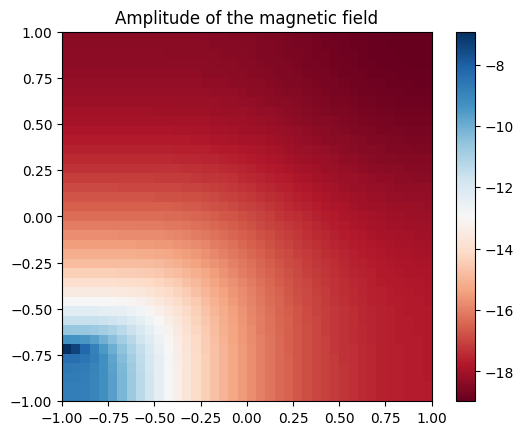

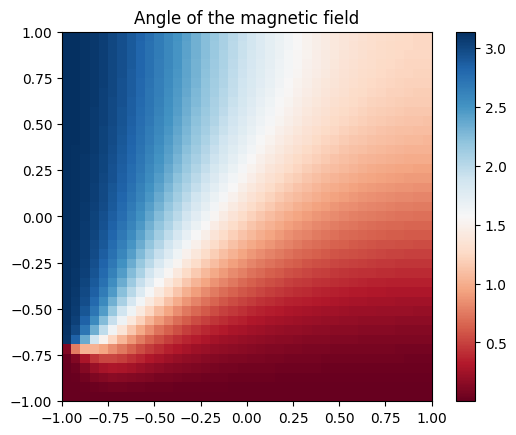

In [58]:
# make simple 2d plots.  Note that these are not really right-- the bin sizes are not all the same on a linear axis.
im = plt.imshow(BAmp.transpose(),cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Amplitude of the magnetic field')
plt.show()

im = plt.imshow(BAngle.transpose(),cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Angle of the magnetic field')
plt.show()

In [59]:
# now calculate Chebyshev coefficients

def ChebyshevN(order,N):
    coefs=np.zeros(N)
    coefs[order]=1
    return np.polynomial.chebyshev.Chebyshev(coefs)

yt=np.array([ChebyshevN(order,Nrho)(rhovalues) for order in range(0,Nrho)]).transpose()
xt=np.array([ChebyshevN(order,Nz)(zvalues) for order in range(0,Nz)])
c=xt@BAmp@yt/Nrho/Nz*4
cang=xt@BAngle@yt/Nz/Nrho*4
c[0,:]=c[0,:]/2
c[:,0]=c[:,0]/2
cang[0,:]=cang[0,:]/2
cang[:,0]=cang[:,0]/2

from numpy.polynomial.chebyshev import chebval2d


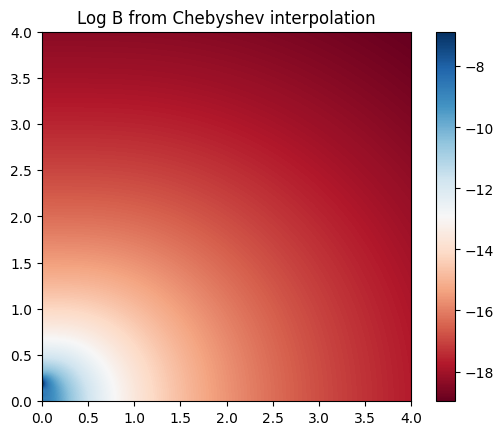

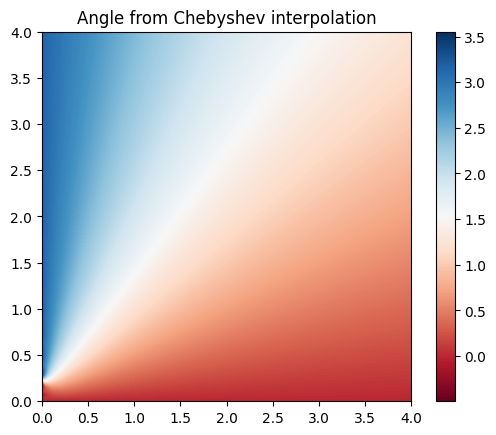

In [60]:
xc = np.linspace(0,4,500)
yc = np.linspace(0,4,500)
xcMapped=mapToCheb(xc,2,2)
ycMapped=mapToCheb(yc,2,2)
Xc,Yc = np.meshgrid(xcMapped, ycMapped) # grid of point
Zc = (chebval2d(Xc,Yc,c)) # evaluation of the function on the grid

Ac= chebval2d(Xc,Yc,cang)
im = plt.imshow(Zc,cmap=plt.cm.RdBu,extent=[0,4,0,4], origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Log B from Chebyshev interpolation')
plt.show()

im = plt.imshow(Ac,cmap=plt.cm.RdBu,extent=[0,4,0,4], origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Angle from Chebyshev interpolation')
plt.show()

# Calculating Helmholtz coils from single coil interpolation
Now we need to define a BHelmCheb(rho,z).  The algorithm needs to
 1. Find the position with respect to coil 1.
 2. If z<0 make z->abs(z). We also need to "flip the sign of $B_\rho$
 3. Calculate the field due to coil 1
 4. Repeat for coil 2



[1.11350494e-05 1.34031801e-04] [-4.86994238e-11  1.71546398e-09  1.53021300e-04]


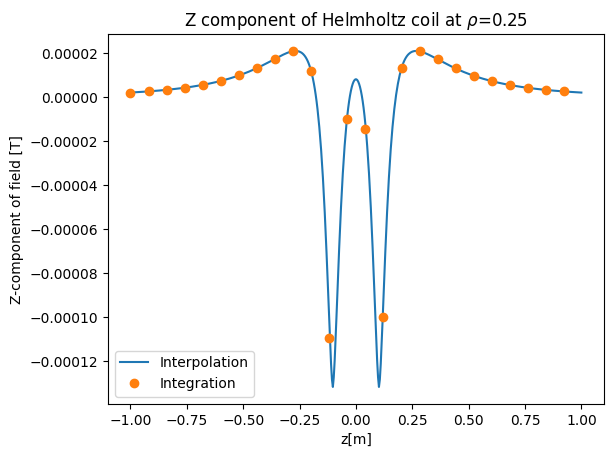

In [67]:
def BCheb(rho,z):
    zmap=mapToCheb(np.abs(z),2,2)
    rhomap=mapToCheb(rho,2,2)
    Bmag=np.exp(chebval2d(zmap,rhomap,c))
    Bang=chebval2d(zmap,rhomap,cang)
    if z<0:
        Bang=-Bang
    return Bmag*np.array([np.sin(Bang),np.cos(Bang)])

def BHelmCheb(rho,z):
    return BCheb(rho,z-0.1025)+BCheb(rho,z+0.1025)

print(BCheb(0.0,0.01),B(0.0,0.01))
zl=np.linspace(-1,1,500)
rhotest=0.25
plt.plot(zl,[BHelmCheb(rhotest,z)[1] for z in zl],label='Interpolation')
#plt.plot(zl,[BHelmCheb(rhotest,z)[1] for z in zl])
plt.plot(zl[::20],[Helm(rhotest,z,0.1025)[2] for z in zl[::20]],'o',label='Integration')
plt.title(r"Z component of Helmholtz coil at $\rho$="+f"{rhotest}")
plt.xlabel('z[m]')
plt.ylabel("Z-component of field [T]")
plt.legend()
plt.show()


In [68]:
from scipy.integrate import solve_ivp

def dydt(t,y): #single coil direction vector
    z,rho=y    
    zmap=mapToCheb(np.abs(z),2,2)
    rhomap=mapToCheb(rho,2,2)
    Bang=chebval2d(zmap,rhomap,cang)
    if z<0:
        Bang=-Bang  
#    print(z,rho,np.cos(Bang),np.sin(Bang),t)
    return np.array([np.cos(Bang),np.sin(Bang)])
def cross(t,y):
    return y[0]
cross.terminal=True
cross.direction=1

def plot(start):
    sol=solve_ivp(dydt,(0.0,20),start,events=cross,rtol=1e-10,method='DOP853')
#    print(sol)
    t=np.linspace(0,sol.t_events[0][0],100)
    sol=solve_ivp(dydt,(0,t[-1]),start,t_eval=t,rtol=1e-10,method='DOP853')
    plt.plot(sol.y[0,:],sol.y[1,:],'r')
    plt.gca().set_aspect('equal')
    plt.plot(sol.y[0,:],-sol.y[1,:],'r')

Text(0, 0.5, 'Position [m]')

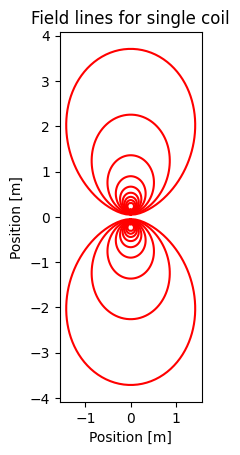

In [69]:
for x in np.linspace(0.050,0.16,9):
    plot(np.array([0.0001,x]))
plt.title("Field lines for single coil")
plt.xlabel("Position [m]")
plt.ylabel("Position [m]")

In [70]:
def dhelmdt(t,y): #helm coil direction vector
    z,rho=y    
    B=BHelmCheb(rho,z)
#    print(z,rho,np.cos(Bang),np.sin(Bang),t)
    return B[::-1]/np.linalg.norm(B) # [::-1] makes order z, rho

def plot(start):
    sol=solve_ivp(dhelmdt,(0.0,40),start,events=cross,rtol=1e-10,method='DOP853')
#    print(sol)
    t=np.linspace(0,sol.t_events[0][0],100)
    sol=solve_ivp(dhelmdt,(0,t[-1]),start,t_eval=t,rtol=1e-10,method='DOP853')
    plt.plot(sol.y[0,:],sol.y[1,:],'r')
    plt.gca().set_aspect('equal')
    plt.plot(sol.y[0,:],-sol.y[1,:],'r')

(-0.5, 0.5)

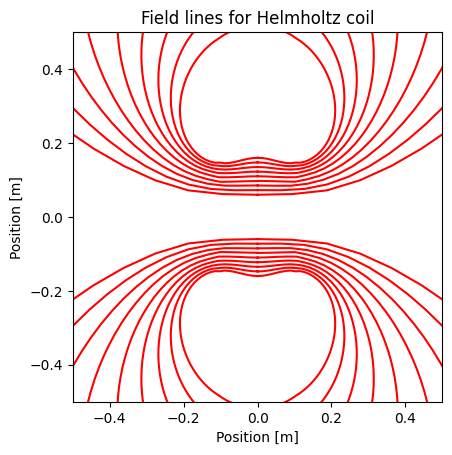

In [71]:
for x in np.linspace(0.06,0.16,9):
    plot(np.array([0.0001,x]))
plt.title("Field lines for Helmholtz coil")
plt.xlabel("Position [m]")
plt.ylabel("Position [m]")
plt.ylim(-.5,.5)
plt.xlim(-.5,.5)